In [1]:
%load_ext autoreload
%autoreload 2

In [20]:
from sc_flow.trainer._trainer import FlowTrainer
import matplotlib.pyplot as plt
import optax
from sc_flow.backends.jax.coupling import independent_coupling
from sc_flow.backends.jax.methods import BaseMethod
from sc_flow.backends.jax.nn._vf import MLPUnconditionalVF
from sc_flow.backends.jax.probability_paths import LinearDiracProbabilityPath
# from sc_flow.backends.torch.methods import BaseMethod

In [21]:
from typing import Any, Literal

import diffrax as dfx
import jax
import jax.numpy as jnp
from diffrax import Euler, ODETerm

from sc_flow.backends.jax._types import ArrayLike, TVfFn
from sc_flow.backends.jax.nn import BaseVelocityField
from abc import ABC, abstractmethod

import flax.linen as nn


class Solver(ABC, nn.Module):
    """Abstract base class for JAX solvers."""

    @abstractmethod
    def solve(
        self,
        source: ArrayLike | None = None,
        return_trajectory: bool = False,
        *,
        solver_kwargs: dict[str, Any] | None = None,
        **kwargs: Any,
    ) -> ArrayLike:
        """Solve method to be implemented by subclasses."""
        ...


class ODESolver(Solver):
    r"""Class for solving neural Ordinary Differential Equations (ODEs).

    :param method: The numerical integration scheme used by diffrax.
        When ``None`` it will be set to :class:`diffrax.Euler`.
    :type method: class: `diffrax.AbstractSolver | None`

    :param num_time_steps: Number of time steps used to construct the time grid over
        :math:`[0, 1]`. When :param:`dt0` is not explicitly passed via :param:`solver_kwargs`,
        the initial step size is set to ``1 / (num_time_steps - 1)``.
    :type num_time_steps: class: `int`

    :param device_id: Identifier for the JAX device on which the ODE is solved.
    :type device_id: class: `Literal["cpu", "gpu", "tpu"] | jax.Device`
    """

    def __init__(
        self,
        method: dfx.AbstractSolver | None = None,
        num_time_steps: int = 500,
        device_id: Literal["cpu", "gpu", "tpu"] = "cpu",
    ) -> None:
        self.method = method or Euler()
        self.num_time_steps = num_time_steps
        self.ts = jnp.linspace(0.0, 1.0, self.num_time_steps)

        if isinstance(device_id, str):
            candidates = [d for d in jax.devices() if d.platform == device_id]
            if not candidates:
                raise ValueError(f"No available device found for platform '{device_id}'")

            self.device = candidates[0]
        else:
            self.device = device_id

    def solve(
        self,
        vf: BaseVelocityField,
        source: ArrayLike,
        return_trajectory: bool = False,
        solver_kwargs: dict[str, Any] | None = None,
        **vf_kwargs: Any,
    ) -> ArrayLike:
        r"""Solve the ODE defined by a neural velocity field.

        This method constructs the vector field from :param:`vf` via
        :meth:`BaseVelocityField.get_vf_fn` and integrates the ODE over the interval
        :math:`[0, 1]` using :func:`diffrax.diffeqsolve`.

        :param vf: The neural velocity field defining the ODE dynamics. It must implement
            :meth:`BaseVelocityField.get_vf_fn`, which should return a callable of the form
            ``vf_fn(t, x, args) -> dx_dt`` compatible with diffrax.
        :type vf: class: `BaseVelocityField`

        :param source: The initial state :math:`x_{t=0}` from which the ODE is integrated.
        :type source: class: `ArrayLike`

        :param return_trajectory: When set to ``True``, the full solution trajectory is
            returned as an array of shape ``(num_time_steps, *source.shape)``. When ``False``, only the final state at
            :math:`t = 1` is returned.
        :type return_trajectory: class: `bool`

        :param solver_kwargs: (Optional) Dictionary of keyword arguments forwarded to
            :func:`diffrax.diffeqsolve`. The following keys are handled explicitly and
            removed from this dictionary:

            * ``"dt0"``: Initial time step size. When not provided, it is set to
              ``1 / (num_time_steps - 1)``.
            * ``"max_steps"``: Maximum number of internal solver steps. Defaults to
              ``10_000``.
            * ``"stepsize_controller"``: Optional instance of
              :class:`diffrax.AbstractStepSizeController`. When not provided, a
              :class:`diffrax.ConstantStepSize` controller is used.

            Any additional entries in :param:`solver_kwargs` are passed to
            :func:`diffrax.diffeqsolve`.
        :type solver_kwargs: class: `dict[str, Any] | None`

        :param vf_kwargs: Additional keyword arguments forwarded to
            :meth:`BaseVelocityField.get_vf_fn`. These can be used to configure the
            behavior of the velocity field at solve time (e.g. conditioning, extra
            parameters, etc.).
        :type vf_kwargs: class: `dict[str, Any]`

        :returns: Either the full solution trajectory or the final state at
            :math:`t = 1`, depending on :param:`return_trajectory`.
        :rtype: class: `ArrayLike`
        """
        if solver_kwargs is None:
            solver_kwargs = {}

        dt0 = 1.0 / (self.num_time_steps - 1)
        dt0 = solver_kwargs.pop("dt0", dt0)
        max_steps = solver_kwargs.pop("max_steps", 10_000)

        stepsize_controller = solver_kwargs.pop("stepsize_controller", None)
        if stepsize_controller is None:
            stepsize_controller = dfx.ConstantStepSize()
        elif not isinstance(stepsize_controller, dfx.AbstractStepSizeController):
            raise TypeError("options['stepsize_controller'] must be an instance of diffrax.AbstractStepSizeController.")

        vector_field: TVfFn = vf.get_vf_fn(**vf_kwargs)
        terms = ODETerm(vector_field)

        source = jax.device_put(source, self.device)

        if return_trajectory:
            saveat = dfx.SaveAt(ts=self.ts)
        else:
            saveat = dfx.SaveAt(t1=True)

        trajectory = dfx.diffeqsolve(
            terms,
            solver=self.method,
            t0=0.0,
            t1=1.0,
            dt0=dt0,
            y0=source,
            saveat=saveat,
            max_steps=max_steps,
            stepsize_controller=stepsize_controller,
            **solver_kwargs,
        )

        if return_trajectory:
            return trajectory.ys
        else:
            return trajectory.ys[-1]

In [22]:
def dummy_time_sampler(rng, n):
    """Sample n time points uniformly from [0, 1]."""
    return jax.random.uniform(rng, shape=(n,), minval=0.0, maxval=1.0)

In [23]:
vf_rng = jax.random.PRNGKey(0)
batch_size = 512
time_sampler = dummy_time_sampler

In [39]:
vf = MLPUnconditionalVF(
    state_dim=2,
    encode_state=True,
    encode_time=True,
    # time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (32,)},
    time_encoder_mlp_kwargs={"hidden_dims": (16,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (64, 64)},
)
probability_path = LinearDiracProbabilityPath(sigma=1.0)
match_fn = independent_coupling
time_sampler = dummy_time_sampler
target_dim = 2
opt = optax.adam(1e-3)


method = BaseMethod(
    vf=vf,
    probability_path=probability_path,
    time_sampler=time_sampler,
    match_fn=match_fn,
    target_dim=target_dim,
    generate_from_noise=False,
    control_key=None,
    optimizer=opt,
    condition_dict={"drug": jnp.ones((batch_size, 1))},
    rng=vf_rng,
)

In [40]:
batch = {
    "src_cell_data": jnp.ones((batch_size, 2)),
    "tgt_cell_data": jnp.ones((batch_size, 2)) * 2,
    "condition": {"dummy_cond": jnp.ones((batch_size, 1))},
}
rng = jax.random.PRNGKey(42)
loss = method.step_fn(rng, batch)

BaseProbabilityPath::compute_xt::t.ndim=1, x0.shape=(512, 2)
PP::t.shape=(512, 1), x0.shape=(512, 2), x1.shape=(512, 2), mu_t.shape=(512, 2)


In [41]:
trainer = FlowTrainer(
    method=method,
    require_prng=True,
)

In [42]:
from abc import ABC, abstractmethod
from typing import Any

import numpy as np
import scanpy as sc


class BaseDummyDataset(ABC):
    """
    Abstract base class for all dummy dataset generators.

    Attributes
    ----------
    random_state : int
        Random seed for reproducibility across all dataset types

    dataset_name : str
        Identifier for the dataset type (e.g., 'blobs', 'moons')
    """

    def __init__(self, random_state: int, n_samples: int, n_features: int, **kwargs):
        """
        Initialize the base dataset generator.

        Parameters
        ----------
        random_state : int, optional (default=42)
            Seed for random number generation to ensure reproducibility
        """
        self.dataset_name = self._get_dataset_name()
        self.random_state = random_state
        self._validate_parameters(random_state, n_samples, n_features, **kwargs)
        self.adata = self._generate(random_state, n_samples, n_features, **kwargs)

    def _create_anndata(
        self, X: np.ndarray, y: np.ndarray | None = None, additional_obs: dict[str, np.ndarray] | None = None
    ) -> sc.AnnData:
        """
        Convert raw numpy arrays into AnnData format with standardized structure.

        Parameters
        ----------
        X : np.ndarray, shape (n_observations, n_features)
            Data matrix where each row is an observation (e.g., a cell)
            and each column is a feature (e.g., a gene or coordinate)

        y : np.ndarray, optional, shape (n_observations,)
            Cluster labels or class assignments for each observation

        additional_obs : dict, optional
            Additional observation-level annotations to store in .obs

        Returns
        -------
        adata : sc.AnnData
            Annotated data object with standardized structure
        """
        # Step 1: Create the core AnnData structure
        adata = sc.AnnData(X=X)

        # Step 2: Create standardized observation names
        n_obs = X.shape[0]
        adata.obs_names = [f"cell_{i}" for i in range(n_obs)]

        # Step 3: Create standardized variable (feature) names
        n_vars = X.shape[1]
        adata.var_names = [f"feature_{i}" for i in range(n_vars)]

        # Step 4: Add cluster labels if provided
        # Labels are stored as strings for categorical data
        if y is not None:
            adata.obs["labels"] = y.astype(str)
            adata.obs["labels"] = adata.obs["labels"].astype("category")

        # Step 5: Add any additional observation-level data
        if additional_obs is not None:
            for key, values in additional_obs.items():
                adata.obs[key] = values

        # Step 6: Store metadata about the dataset
        adata.uns["dataset_info"] = self._create_metadata(X)

        return adata

    def _create_metadata(self, X: np.ndarray) -> dict[str, Any]:
        """
        Create standardized metadata dictionary for the dataset.

        Parameters
        ----------
        X : np.ndarray
            The data matrix to extract shape information from

        Returns
        -------
        metadata : dict
            Dictionary containing dataset information
        """
        return {
            "name": self.dataset_name,
            "n_observations": X.shape[0],
            "n_features": X.shape[1],
            "random_state": self.random_state,
            "generator": self.__class__.__name__,
        }

    def _validate_parameters(self, random_state, n_samples: int, n_features: int, **kwargs) -> None:
        """
        Validate common parameters to prevent errors.

        Parameters
        ----------
        n_samples : int
            Number of observations to generate

        n_features : int
            Number of features (dimensions) for each observation

        Raises
        ------
        ValueError : If parameters are invalid
        """
        if not isinstance(n_samples, int):
            raise TypeError(f"n_samples must be an integer, got {type(n_samples)}")

        if not isinstance(n_features, int):
            raise TypeError(f"n_features must be an integer, got {type(n_features)}")

        if not isinstance(random_state, int):
            raise TypeError(f"random_state must be an integer, got {type(random_state)}")

        if n_samples <= 0:
            raise ValueError(f"n_samples must be positive, got {n_samples}")

        if n_features <= 0:
            raise ValueError(f"n_features must be positive, got {n_features}")

        self._validate_additional_parameters(**kwargs)

    @abstractmethod
    def _validate_additional_parameters(self, **kwargs) -> None:
        """Validate dataset-specific parameters."""
        raise NotImplementedError

    @abstractmethod
    def _get_dataset_name(self) -> str:
        """
        Return the name identifier for this dataset type.

        This is an abstract method - each child class must implement it.
        Example: BlobsDataset would return "blobs"

        Returns
        -------
        str : Name of the dataset
        """
        raise NotImplementedError

    @abstractmethod
    def _generate(self, **kwargs) -> sc.AnnData:
        """
        Generate the dataset with specific parameters.

        This is an abstract method - each child class must implement its own
        generation logic using sklearn or custom algorithms.

        Parameters
        ----------
        **kwargs : dict
            Dataset-specific parameters (e.g., n_samples, noise level)

        Returns
        -------
        adata : sc.AnnData
            Generated dataset wrapped in AnnData format
        """
        raise NotImplementedError

In [43]:
import scanpy as sc
from sklearn import datasets


class MoonsDataset(BaseDummyDataset):
    """
    Generate two interleaving half-circles (moons).

    Parameters
    ----------
    random_state : int, optional (default=42)
        Seed for random number generation to ensure reproducibility

    n_samples : int, optional (default=1000)
        Total number of samples to generate

    noise : float, optional (default=0.0)
        Standard deviation of Gaussian noise added to the data

    shuffle : bool, optional (default=True)
        Whether to shuffle the samples after generation
    """

    def __init__(self, random_state: int = 42, n_samples: int = 1000, noise: float = 0.0, shuffle: bool = True):
        """Initialization"""
        super().__init__(random_state, n_samples, n_features=2, noise=noise, shuffle=shuffle)

    def _get_dataset_name(self) -> str:
        """Return identifier for this dataset type."""
        return "moons"

    def _validate_additional_parameters(self, **kwargs):
        """Validate dataset-specific parameters."""
        noise = kwargs["noise"]
        shuffle = kwargs["shuffle"]

        if not isinstance(noise, int | float):
            raise TypeError(f"noise must be a number, got {type(noise)}")

        if noise < 0:
            raise ValueError(f"noise must be non-negative, got {noise}")

        if not isinstance(shuffle, bool):
            raise TypeError(f"shuffle must be a boolean, got {type(shuffle)}")

    def _generate(self, random_state, n_samples, n_features, noise, shuffle) -> sc.AnnData:
        """
        Generate interleaving half-circles (moons) dataset.

        Returns
        -------
        adata : sc.AnnData
            Dataset with two interleaving half-circles labeled as class 0 and 1
        """
        # Step 1: Generate moons using sklearn
        X, y = datasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state, shuffle=shuffle)

        # Step 2: Wrap in AnnData format
        adata = self._create_anndata(X, y)

        # Step 3: Add moons-specific metadata
        adata.uns["dataset_info"]["noise"] = noise
        adata.uns["dataset_info"]["shuffle"] = shuffle

        return adata

In [44]:
adata = MoonsDataset()._generate(n_samples=10_000, random_state=42, n_features=2, noise=0.1, shuffle=False)

In [45]:
class DummyTrainLoader:
    """Dummy training data loader for the moons dataset."""

    def __init__(self, adata, batch_size):
        self.adata = adata
        self.batch_size = batch_size

    def sample(self, _):
        """Sample a batch of data for training."""
        return {
            "src_cell_data": jnp.array(np.random.randn(self.batch_size, self.adata.X.shape[1])),
            "tgt_cell_data": jnp.array(
                self.adata.X[np.random.choice(np.arange(1, self.adata.shape[0]), size=self.batch_size), :]
            ),
        }

In [46]:
train_loader = DummyTrainLoader(adata=adata, batch_size=512)

In [47]:
train_loader_key = jax.random.PRNGKey(0)

In [48]:
data = train_loader.sample(None)

In [49]:
data

{'src_cell_data': Array([[ 0.03177011, -1.2337208 ],
        [ 2.1215036 , -0.12983584],
        [-0.14643835, -0.09179483],
        ...,
        [ 0.28866887, -0.6238556 ],
        [ 1.4040582 ,  0.3667362 ],
        [-1.2738731 , -1.1665161 ]], dtype=float32),
 'tgt_cell_data': Array([[ 1.3886265 , -0.39288846],
        [ 0.7806739 , -0.37415835],
        [ 1.5010947 , -0.23806037],
        ...,
        [ 0.8492538 , -0.24854025],
        [-0.41067916,  0.8483307 ],
        [ 1.7053645 , -0.14575505]], dtype=float32)}

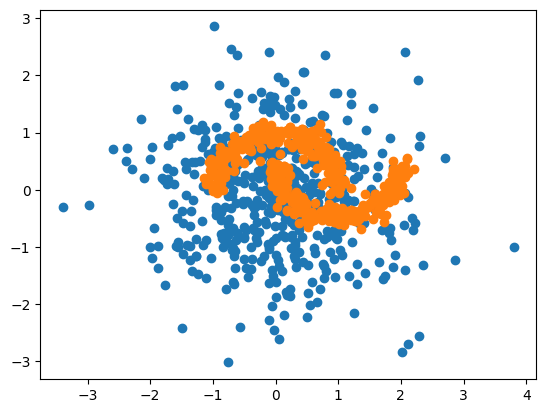

In [50]:
plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])

In [51]:
vf

MLPUnconditionalVF(
    # attributes
    state_dim = 2
    encode_state = True
    encode_time = True
    time_features_id = None
    time_features_fn = None
    num_time_features = 256
    max_period = 1000
    time_features_kwargs = {}
    state_encoder_output_dim = 32
    time_encoder_output_dim = 16
    state_encoder_mlp_kwargs = {'hidden_dims': (32,)}
    time_encoder_mlp_kwargs = {'hidden_dims': (16,)}
    vf_decoder_mlp_kwargs = {'hidden_dims': (64, 64)}
    conditioning_id = 'concat'
    conditioning_fn = None
    conditioning_kwargs = None
    condition_encoder_input_layers = None
    condition_encoder_output_dim = 32
    condition_encoder_pooling_mode = 'mean'
    condition_encoder_pooling_kwargs = {}
    condition_encoder_output_layers_kwargs = None
    source_encoder_mlp_kwargs = None
    source_encoder_output_dim = 16
)

In [52]:
trainer.fit(train_dataloader=train_loader, num_iterations=10_000, valid_freq=10000, prng=train_loader_key)

  0%|                                                                                                          | 0/10000 [00:00<?, ?it/s]Validation step requires validation data. Please prepare validation data with `model.prepare_validation_data()` method.


BaseProbabilityPath::compute_xt::t.ndim=1, x0.shape=(512, 2)
PP::t.shape=(512, 1), x0.shape=(512, 2), x1.shape=(512, 2), mu_t.shape=(512, 2)


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:32<00:00, 308.95it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

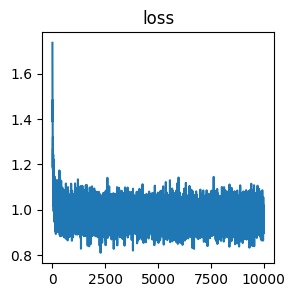

In [53]:
trainer.plot_training_logs()

In [54]:
x = jnp.array(np.random.randn(512, 2))

In [55]:
preds = trainer._method.predict(data["src_cell_data"])

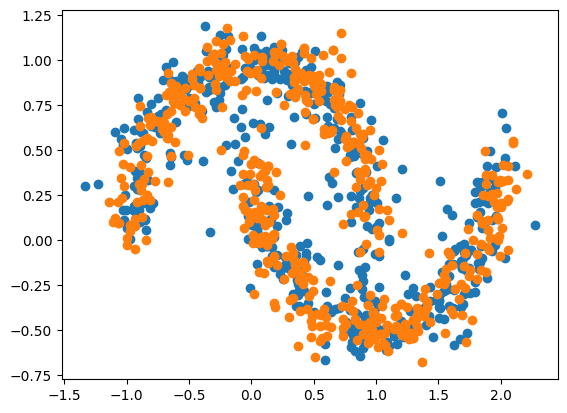

In [57]:
plt.scatter(preds[:, 0], preds[:, 1])
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])
# plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])